# Skin Cancer Detection with Convolutional Neural Networks

In this project, we develop a deep learning model using Keras for skin cancer detection. We use the "Skin Cancer MNIST: HAM10000" dataset, which contains images of different types of skin lesions. The goal is to classify these images into several skin cancer categories.

You can check the deployment of this model on [https://melanoma-project.vercel.app/](https://melanoma-project.vercel.app/)

# Project Start

In [3]:
# import libraries
# for data manipulation
import pandas as pd
import numpy as np

# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from keras.layers import Conv2D , MaxPooling2D ,Dropout , Flatten , Dense ,BatchNormalization ,Concatenate ,Input 
from keras.models import Sequential ,Model

# SK Learn library to split train and test data
from sklearn.model_selection import train_test_split

# other libraries
import cv2
import os
from PIL import Image
from tensorflow.keras.preprocessing.image import img_to_array, load_img

## Data Loading

In [4]:
path_dir_option = ''

if path_dir_option == 'local':

    data_hmnist_path =os.path.join('archive', 'HAM10000_metadata.csv')

else:

    data_hmnist_path = os.path.join('/kaggle/input','skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

print(data_hmnist_path)

data_hmnist = pd.read_csv(data_hmnist_path)

data_hmnist.head()

/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


# Data Analysis

Let's start with an exploratory data analysis.

In [5]:
#add column with path to image

data_hmnist['path'] = data_hmnist['image_id'].apply(lambda x: os.path.join(data_hmnist_path, 'HAM10000_images', x + '.jpg'))
data_hmnist.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...


In [6]:
# checking for the null values
data_hmnist.isna().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
path             0
dtype: int64

In [7]:
# replacing the missing values of age with mean
data_hmnist['age'] = data_hmnist['age'].fillna(round(data_hmnist['age'].mean()))

data_hmnist.isna().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
path            0
dtype: int64

After reviewing the data, we can see that there are 7 different classes of skin cancer. Each class has a different number of images.

## Statistical Analysis

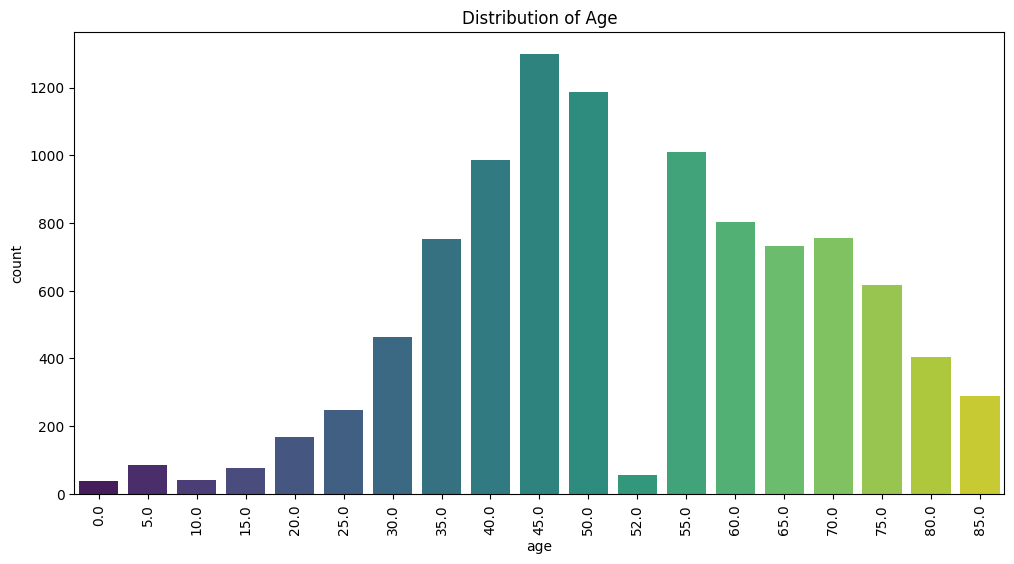

In [8]:
import seaborn as sns

import matplotlib.pyplot as plt

# distribution of ages
plt.figure(figsize=(12,6))

sns.countplot(data=data_hmnist ,x='age',palette='viridis')

plt.title('Distribution of Age')

plt.xticks(rotation=90)

plt.show()

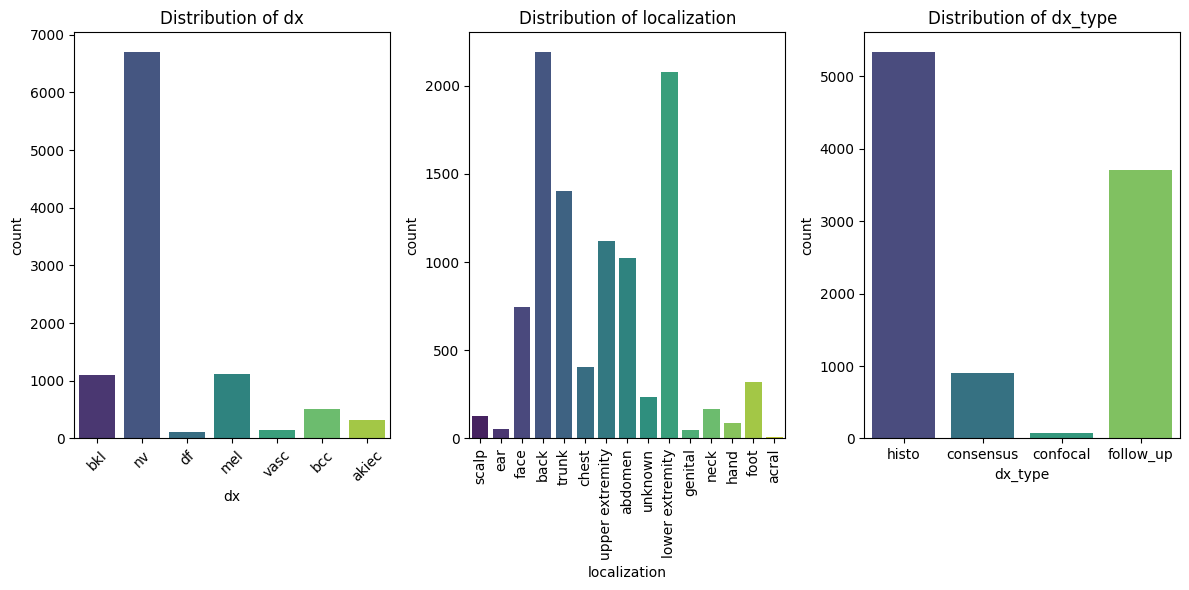

In [9]:
# distribution of other features

# dx, dx-type, localization
plt.figure(figsize=(12, 6))

plt.subplot(1,3,1)
sns.countplot(data=data_hmnist , x='dx' ,palette='viridis')
plt.title('Distribution of dx')
plt.xticks(rotation=45)

plt.subplot(1,3,2)
sns.countplot(data=data_hmnist,x='localization' ,palette='viridis')
plt.title('Distribution of localization')
plt.xticks(rotation=90)

plt.subplot(1,3,3)
sns.countplot(data=data_hmnist , x = 'dx_type' , palette='viridis')
plt.title('Distribution of dx_type')

plt.tight_layout()
plt.show()

In [10]:
# replacing unknown values in the sex column with male
# to prevent having extra column during label encoding

data_hmnist['sex'] = data_hmnist['sex'].replace('unknown', 'male')

data_hmnist['sex'].value_counts()

sex
male      5463
female    4552
Name: count, dtype: int64

In [11]:
# X_features include - age, dx_type, sex, localization

# y_feature - dx
metadata_features = data_hmnist[['age', 'dx_type', 'sex', 'localization']].copy()
metadata_features.head()

,age,dx_type,sex,localization
0,80.0,histo,male,scalp
1,80.0,histo,male,scalp
2,80.0,histo,male,scalp
3,80.0,histo,male,scalp
4,75.0,histo,male,ear


Categorical data is converted using one hot encoding.

In [12]:
# changing categorical data into numerical data using dummies

metadata_features = pd.get_dummies(metadata_features, columns=['dx_type', 'sex', 'localization'], drop_first=True, dtype=int)
metadata_features.head()

,age,dx_type_consensus,dx_type_follow_up,dx_type_histo,sex_male,localization_acral,localization_back,localization_chest,localization_ear,localization_face,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity
0,80.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,80.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,80.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,80.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,75.0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [13]:
# normalizing the age value

metadata_features['age'] = metadata_features['age'] / metadata_features['age'].max()
metadata_features

,age,dx_type_consensus,dx_type_follow_up,dx_type_histo,sex_male,localization_acral,localization_back,localization_chest,localization_ear,localization_face,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity
0,0.941176,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0.941176,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,0.941176,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,0.941176,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0.882353,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,0.470588,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10011,0.470588,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10012,0.470588,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10013,0.941176,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0


Converting the 7 labels to 2 categories:

- 'Melanocytic Nevi (nv)' - Non Cancerous (0)
- 'Benign Keratosis-like Lesions (bkl)' - Non Cancerous (0)
- 'Dermatofibroma (df)' - Non Cancerous (0)
- 'Melanoma (mel)' - Cancerous (1)
- 'Vascular Lesions (vasc)' - Non Cancerous (0)
- 'Basal Cell Carcinoma (bcc)' - Cancerous (1)
- 'Actinic Keratoses and Intraepithelial Carcinoma (akiec)' - Cancerous (1)roso (1)


In [14]:
# Each type of 
label_mapping = {
    "nv": 0,
    "bkl": 1,
    "df": 2,
    "mel": 3,
    "vasc": 4,
    "bcc": 5,
    "akiec": 6
}

In [15]:
label_mapping2 = {
    "nv": 0,
    "bkl": 0,
    "df": 0,
    "mel": 1,
    "vasc": 0,
    "bcc": 1,
    "akiec": 1
}

## Image Loading

In [16]:
# function to load_image data

def load_image(image_id  , image_folder):

    image_path = os.path.join(image_folder , f'{image_id}.jpg')

    return Image.open(image_path)

In [17]:
if path_dir_option == 'local':
    image_folder1 = os.path.join('archive', 'HAM10000_images_part_1')
    image_folder2 = os.path.join('archive', 'HAM10000_images_part_2')

else:
    image_folder1 = '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1'
    image_folder2 = '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2'


image_data = []
labels1 = []
labels2 = []


for idx,row in data_hmnist.iterrows():
    i_id = row['image_id']
    dx   = row['dx']
    
    try:
        image = load_image(i_id , image_folder1)

        
    except FileNotFoundError:
        image = load_image(i_id , image_folder2)

    image = image.resize((128,128))
    image = img_to_array(image) /255.0

    image_data.append(image)
    labels1.append(label_mapping[dx])
    labels2.append(label_mapping2[dx])

In [18]:
classes = ['Melanocytic Nevi (nv)',

           'Benign Keratosis-like Lesions (bkl)',

           'Dermatofibroma (df)',

           'Melanoma (mel)',

           'Vascular Lesions (vasc)',

           'Basal Cell Carcinoma (bcc)',

           'Actinic Keratoses and Intraepithelial Carcinoma (akiec)']

In [19]:
classes2 = ['Non Cancerous',

            'Cancerous']

Let's display some images from the dataset. 

In [20]:
def show_samples(i_dex):
    plt.imshow(image_data[i_dex])
    plt.xlabel(f'{classes[labels1[i_dex]]} - {classes2[labels2[i_dex]]}')
    plt.show()

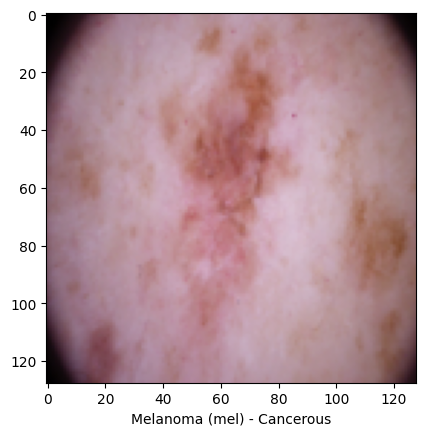

In [21]:
show_samples(1746)

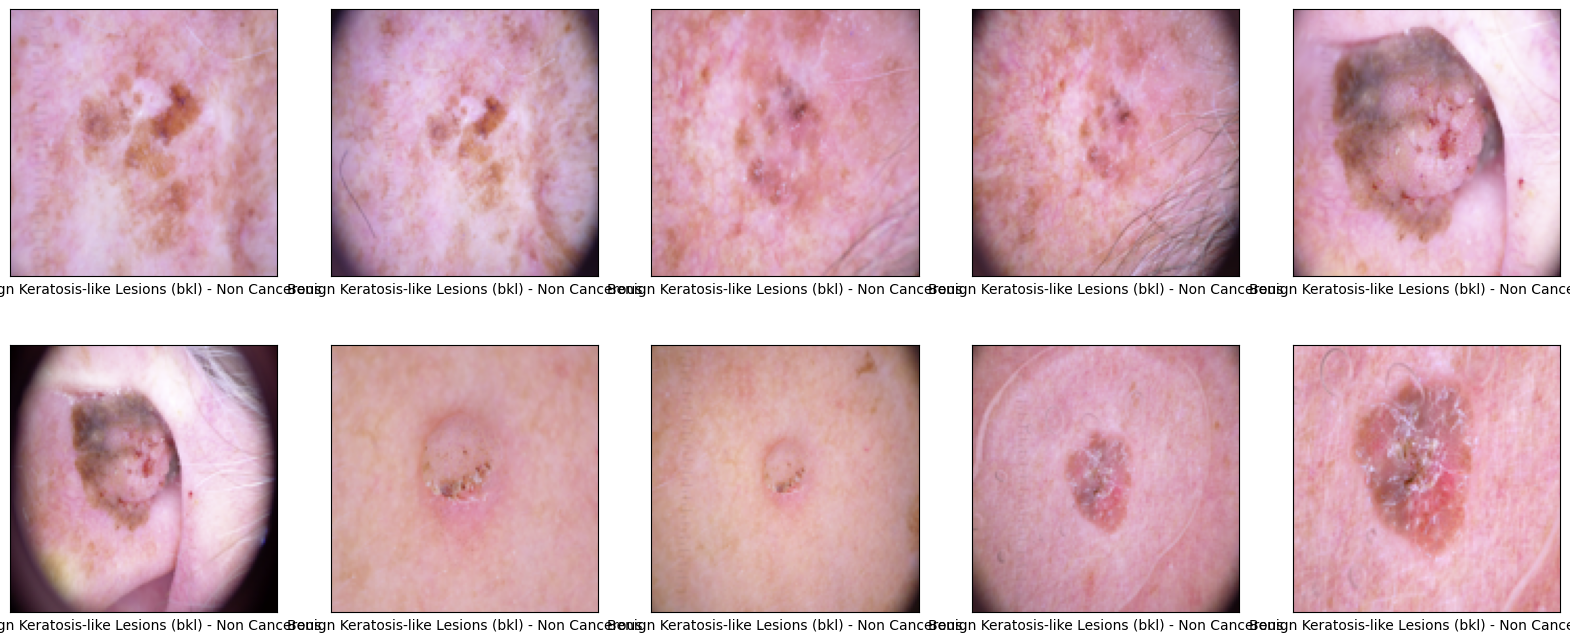

In [22]:
plt.figure(figsize=(20,8))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.xlabel(f'{classes[labels1[i]]} - {classes2[labels2[i]]}')
    plt.imshow(image_data[i])

We have a total of 10,015 images.

In [23]:
print(len(image_data))
print(len(labels1))

10015
10015


## Data Augmentation
Data augmentation will be applied to increase the number of images and improve model performance..

First, we define the image generator with data augmentation.
In this case, augmentation is applied only to training images with rotations and horizontal/vertical flips..

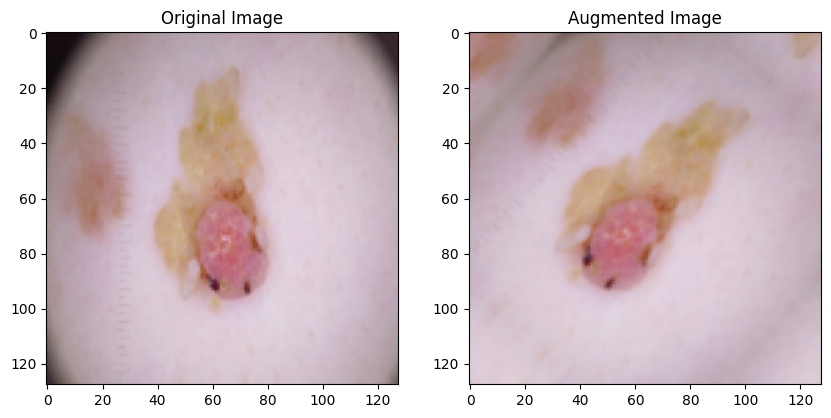

In [24]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.4),
])

result = data_augmentation(image_data[10])

plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image_data[10])

# Augmented image
plt.subplot(1, 2, 2)
plt.title("Augmented Image")
plt.imshow(result)

plt.show()

# Creation of Training and Test Data

Convert labels to numpy array and apply one hot encoding.

In [25]:
y = np.array(labels1)
from tensorflow.keras.utils import to_categorical
y_encoded = to_categorical(y,num_classes=7)
y_encoded[3]
y_encoded.shape

(10015, 7)

In [26]:
X_image = np.array(image_data)
X_image.shape

(10015, 128, 128, 3)

Split the data into training and test sets, with 80% for training and 20% for testing.

In [27]:
X_train_image, X_test_image, y_encoded_train ,y_encoded_test = train_test_split(X_image, y_encoded ,test_size=.2 ,random_state=42)

Finally, we apply data augmentation to the training images.


In [28]:
#aumento de datos de datos prueba
print('Antes del aumento de datos')
print(X_train_image.shape)
print(y_encoded_train.shape)

X_train_augmented = []

y_encoded_train_augmented = []
#new data
for i in range(5000):
    modified_image =  data_augmentation(X_train_image[i])
    X_train_augmented.append(modified_image)
    y_encoded_train_augmented.append(y_encoded_train[i])

#rewrite the original 
for i in range(len(X_train_image)):
    X_train_augmented.append(X_train_image[i])
    y_encoded_train_augmented.append(y_encoded_train[i])
    

X_train_image =  np.array(X_train_augmented)
y_encoded_train = np.array(y_encoded_train_augmented)


print('Despues del aumento de datos')

print(X_train_image.shape)
print(y_encoded_train.shape)

Antes del aumento de datos
(8012, 128, 128, 3)
(8012, 7)
Despues del aumento de datos
(13012, 128, 128, 3)
(13012, 7)


Number of training and test samples

In [29]:
print(X_train_image.shape)
print(y_encoded_train.shape)

print(X_test_image.shape)
print(y_encoded_test.shape)

(13012, 128, 128, 3)
(13012, 7)
(2003, 128, 128, 3)
(2003, 7)


# Convolutional Neural Network Model

In [30]:
# creating a CNN + ANN model

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))
model.add(Dropout(0.5))
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(32, activation='relu'))

# o/p layer
model.add(Dense(7, activation='softmax'))

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model compilation.

In [31]:

from tensorflow.keras import metrics

# Model compilation with additional metrics
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall')
    ]
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,787,975 (56.41 MB)

 Trainable params: 14,787,975 (56.41 MB)

 Non-trainable params: 0 (0.00 B)

Model training.

In [33]:
history = model.fit(X_train_image, y_encoded_train,
                    validation_data=(X_test_image, y_encoded_test),
                    batch_size=32,
                    validation_split=.2,
                    epochs=20)

Epoch 1/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 308s 756ms/step - accuracy: 0.6749 - loss: 0.9769 - precision: 0.7862 - recall: 0.5567 - val_accuracy: 0.6705 - val_loss: 0.8981 - val_precision: 0.8124 - val_recall: 0.5122
Epoch 2/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 307s 755ms/step - accuracy: 0.6968 - loss: 0.8257 - precision: 0.8150 - recall: 0.5894 - val_accuracy: 0.6860 - val_loss: 0.8149 - val_precision: 0.7713 - val_recall: 0.6450
Epoch 3/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 310s 761ms/step - accuracy: 0.7179 - loss: 0.7507 - precision: 0.8209 - recall: 0.6242 - val_accuracy: 0.7079 - val_loss: 0.7952 - val_precision: 0.8094 - val_recall: 0.6126
Epoch 4/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 327s 773ms/step - accuracy: 0.7301 - loss: 0.7155 - precision: 0.8312 - recall: 0.6403 - val_accuracy: 0.7174 - val_loss: 0.7686 - val_precision: 0.8129 - val_recall: 0.6031
Epoch 5/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 322s 790ms/step - accuracy: 0.7487 - loss: 0.6710 - precision: 0.8349 - recall: 0.6661 - val_accuracy: 0

# Model Evaluation

Below is the loss function and model accuracy on the test dataset.

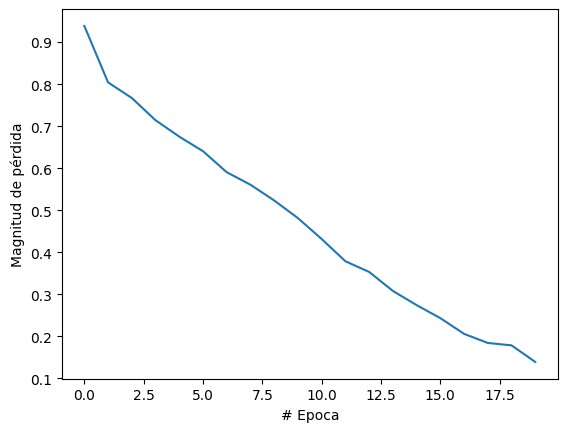

In [37]:
# View loss function
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(history.history["loss"])

Muestra de predicciones

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


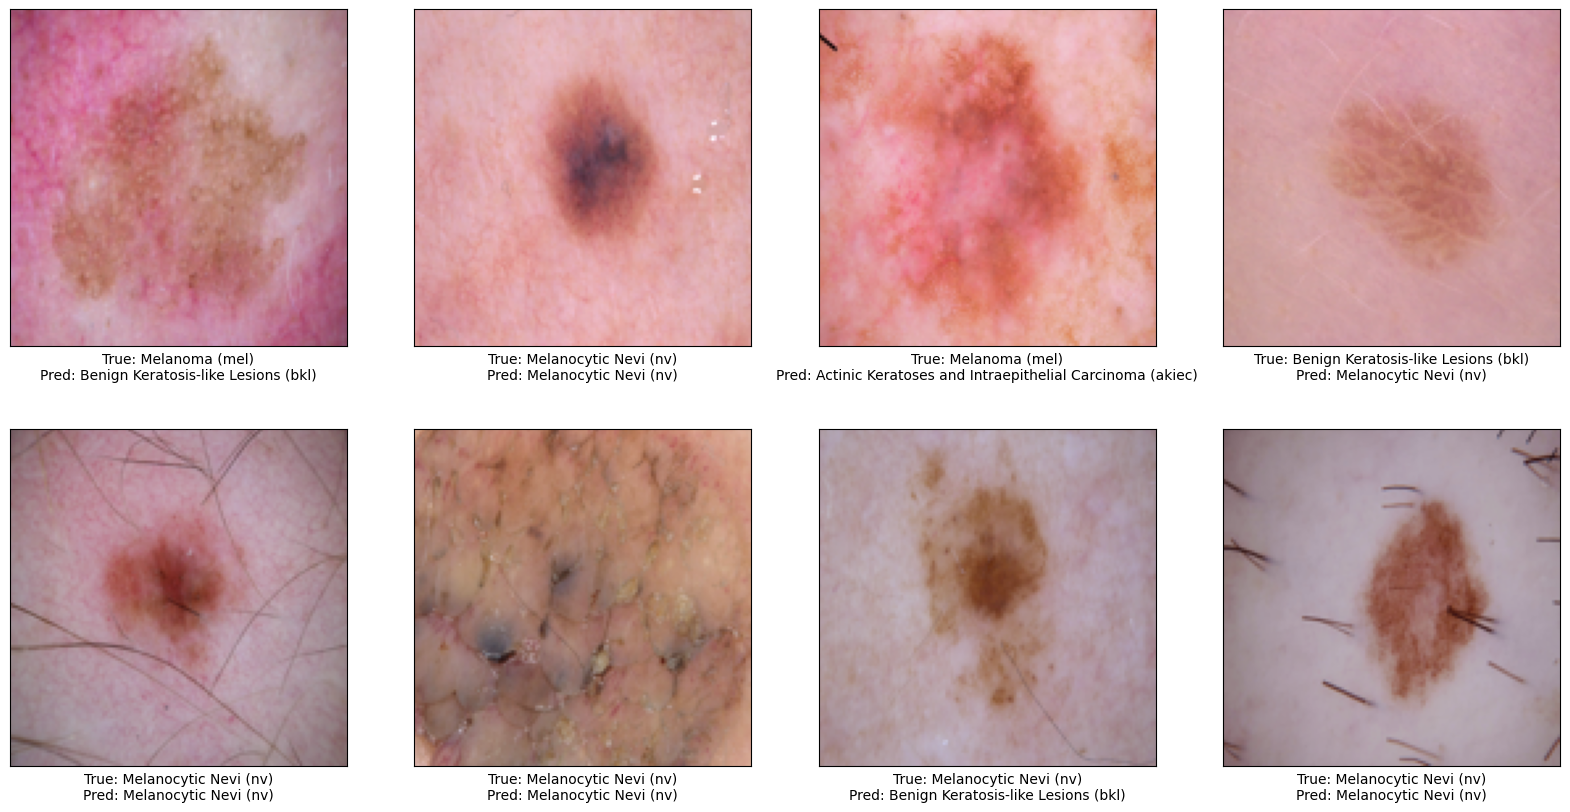

In [38]:
plt.figure(figsize=(20, 10))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_test_image[i])
    true_label = classes[np.argmax(y_encoded_test[i])]
    pred_label = classes[np.argmax(model.predict(X_test_image[i].reshape(1, 128, 128, 3)))]
    plt.xlabel(f'True: {true_label}\nPred: {pred_label}')
plt.show()

The model's accuracy on the test images is taken as the percentage of correct classifications.

In [39]:
model.evaluate(X_test_image, y_encoded_test)


63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.7235 - loss: 1.3251 - precision: 0.7430 - recall: 0.7063


[1.3521702289581299, 0.7269096374511719, 0.7473903894424438, 0.714927613735199]

# Additional Metric: F1-score
To further evaluate the model, we can calculate the F1-score, which combines precision and recall into a single metric.

In [40]:
from sklearn.metrics import f1_score

# Get predictions for the test set
y_pred = model.predict(X_test_image)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_encoded_test, axis=1)

# Calculate F1-score (macro for multiclass)
f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
print(f"F1-score (macro): {f1:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step
F1-score (macro): 0.4638


# Confusion Matrix
To complement accuracy, precision, recall, and F1-score, we can visualize a confusion matrix for the test set.

- Each **row** corresponds to the *true* class.
- Each **column** corresponds to the *predicted* class.
- Values on the **diagonal** are correct predictions.
- Values **off the diagonal** are misclassifications.

For this multiclass skin cancer problem, a good model will have high values on the diagonal (correctly classified lesions) and low values elsewhere (few confusions between classes).

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step


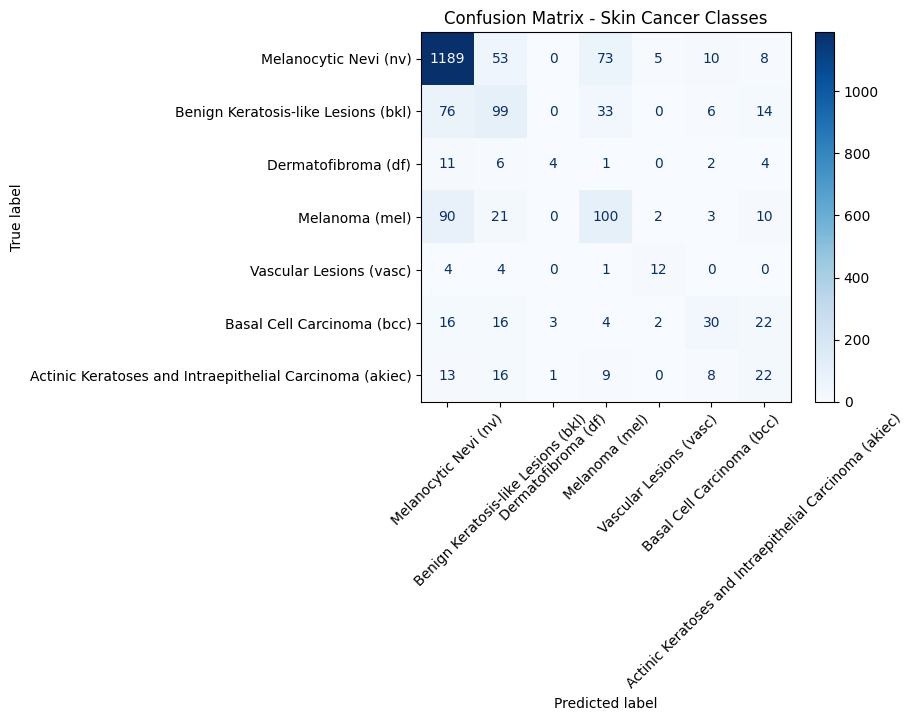

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions for the test set
y_pred = model.predict(X_test_image)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_encoded_test, axis=1)

# Compute and plot confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Skin Cancer Classes")
plt.show()


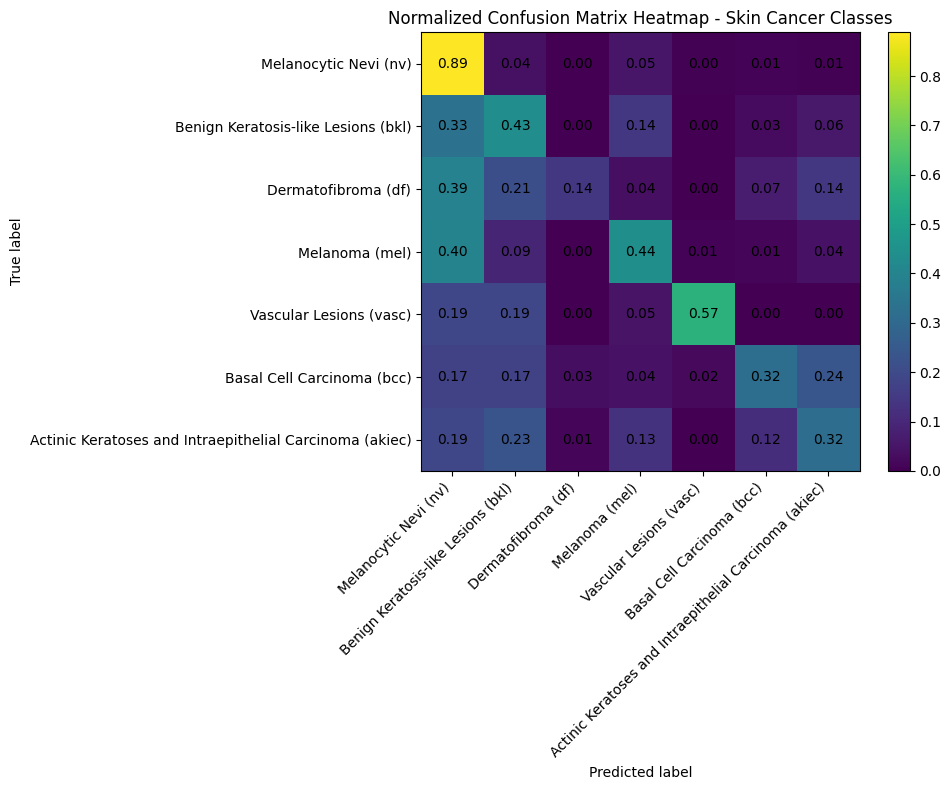

In [42]:
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm)
plt.colorbar()

plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)

# Annotate values (percentages)
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}",
                 ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix Heatmap - Skin Cancer Classes")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion-matrix-heatmap.png", dpi=300)
plt.show()


# Saving the model in Kaggle for later use in a web page.

In [43]:
# Save the model

model.save("/kaggle/working/model.h5")

In [44]:
import tensorflow as tf

model = tf.keras.models.load_model("/kaggle/working/model.h5")

In [46]:
model.export("/kaggle/working/saved_model")

Saved artifact at '/kaggle/working/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  133174345147744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174345151440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174343390608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174343395184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174343554800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174343557616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174343557792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174343562016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174343562192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174343562544: TensorSpec(shape=(), dtype=tf.resource, name=None)


Saving in tflite format

In [47]:
converter = tf.lite.TFLiteConverter.from_saved_model(
    "/kaggle/working/saved_model"
)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

tflite_model = converter.convert()

W0000 00:00:1768274194.808097      32 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1768274194.809712      32 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.


In [48]:
with open("/kaggle/working/model.tflite", "wb") as f:
    f.write(tflite_model)

Saving in onnx format

In [49]:
!pip install tflite2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.2/153.2 kB 3.8 MB/s eta 0:00:00ta 0:00:01


In [51]:
from tflite2onnx import convert
 
tflite_path = "/kaggle/working/model.tflite"
onnx_path = "/kaggle/working/model.onnx"
 
convert(tflite_path, onnx_path)